# MLTP Experiment 3

# Concrete Comperessive Strength

#### Subject:Machine Learning Theory and Practice
#### Objective:Understanding Simple and Multiple Linear regression

# Importing Required Libraries

In [2]:
import pandas as pd

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler


# Task 1:Exploratory Data Analysis (EDA)

In [5]:
# Load the dataset
df = pd.read_csv(r"C:\Users\Admin\Desktop\mlLab\lab\Concrete_data.csv")

In [6]:
# Display first 5 Rows
print("First 5 rows:")
display(df.head())

First 5 rows:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)",Unnamed: 9
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,79.99,NaN
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,61.89,NaN
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270.0,40.27,NaN
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365.0,41.05,NaN
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360.0,44.30,NaN


In [7]:
# Display last 5 Rows
print("Last 5 rows:")
display(df.tail())

Last 5 rows:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)",Unnamed: 9
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28.0,31.18,NaN
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28.0,23.70,NaN
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28.0,32.77,NaN
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28.0,32.40,NaN
1030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Dataset info
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1031 entries, 0 to 1030
Data columns (total 10 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   float64
 8   Concrete compressive strength(MPa, megapascal

In [9]:
# Dataset Dimensions
print("Dataset Shape:")
print(df.shape)



Dataset Shape:
(1031, 10)


In [10]:
# Dataset Information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1031 entries, 0 to 1030
Data columns (total 10 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   float64
 8   Concrete compressive strength(MPa, meg

In [11]:
# Statistical Summary
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)",Unnamed: 9
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,0.0
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961,NaN
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742,NaN
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000,NaN
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000,NaN
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000,NaN
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000,NaN
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000,NaN


In [12]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Cement (component 1)(kg in a m^3 mixture)                   1
Blast Furnace Slag (component 2)(kg in a m^3 mixture)       1
Fly Ash (component 3)(kg in a m^3 mixture)                  1
Water  (component 4)(kg in a m^3 mixture)                   1
Superplasticizer (component 5)(kg in a m^3 mixture)         1
Coarse Aggregate  (component 6)(kg in a m^3 mixture)        1
Fine Aggregate (component 7)(kg in a m^3 mixture)           1
Age (day)                                                   1
Concrete compressive strength(MPa, megapascals)             1
Unnamed: 9                                               1031
dtype: int64


#### Data Visualization

#### Correlation Heatmap

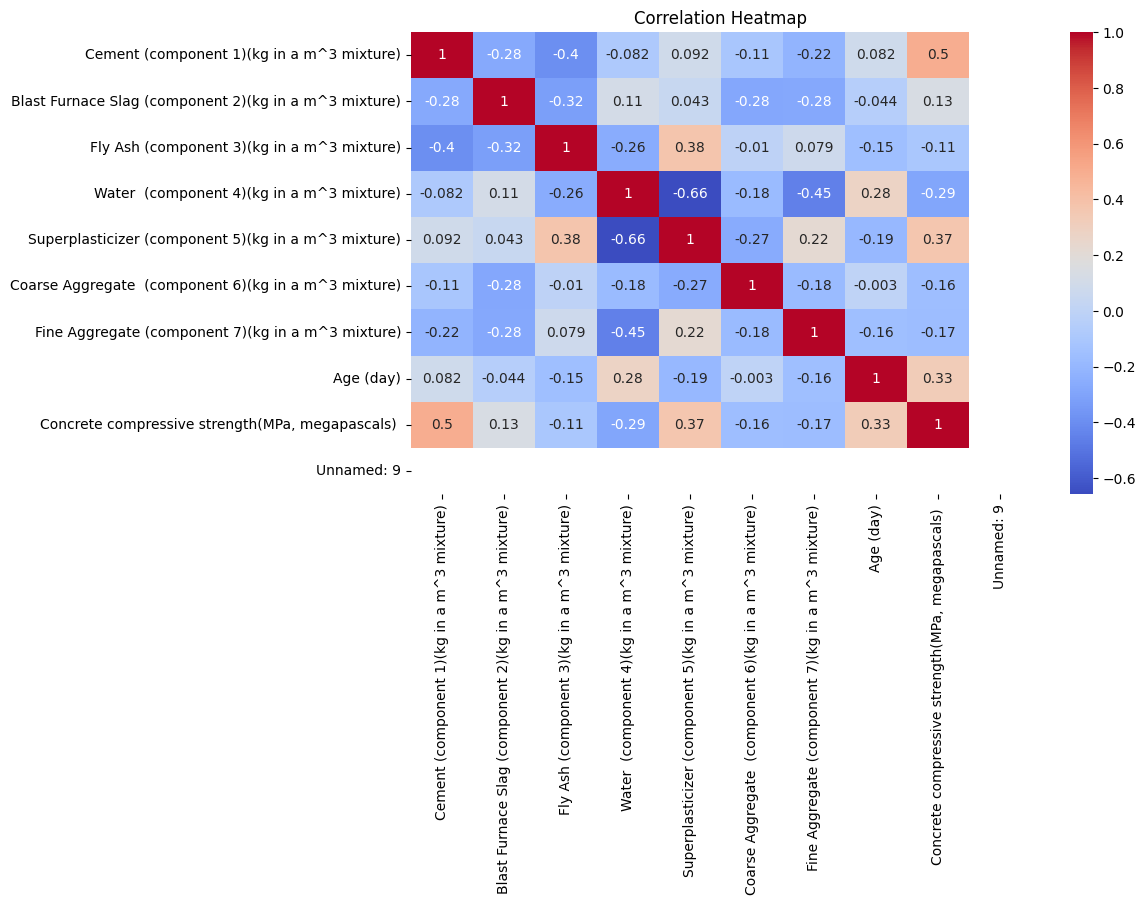

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Pair Plot

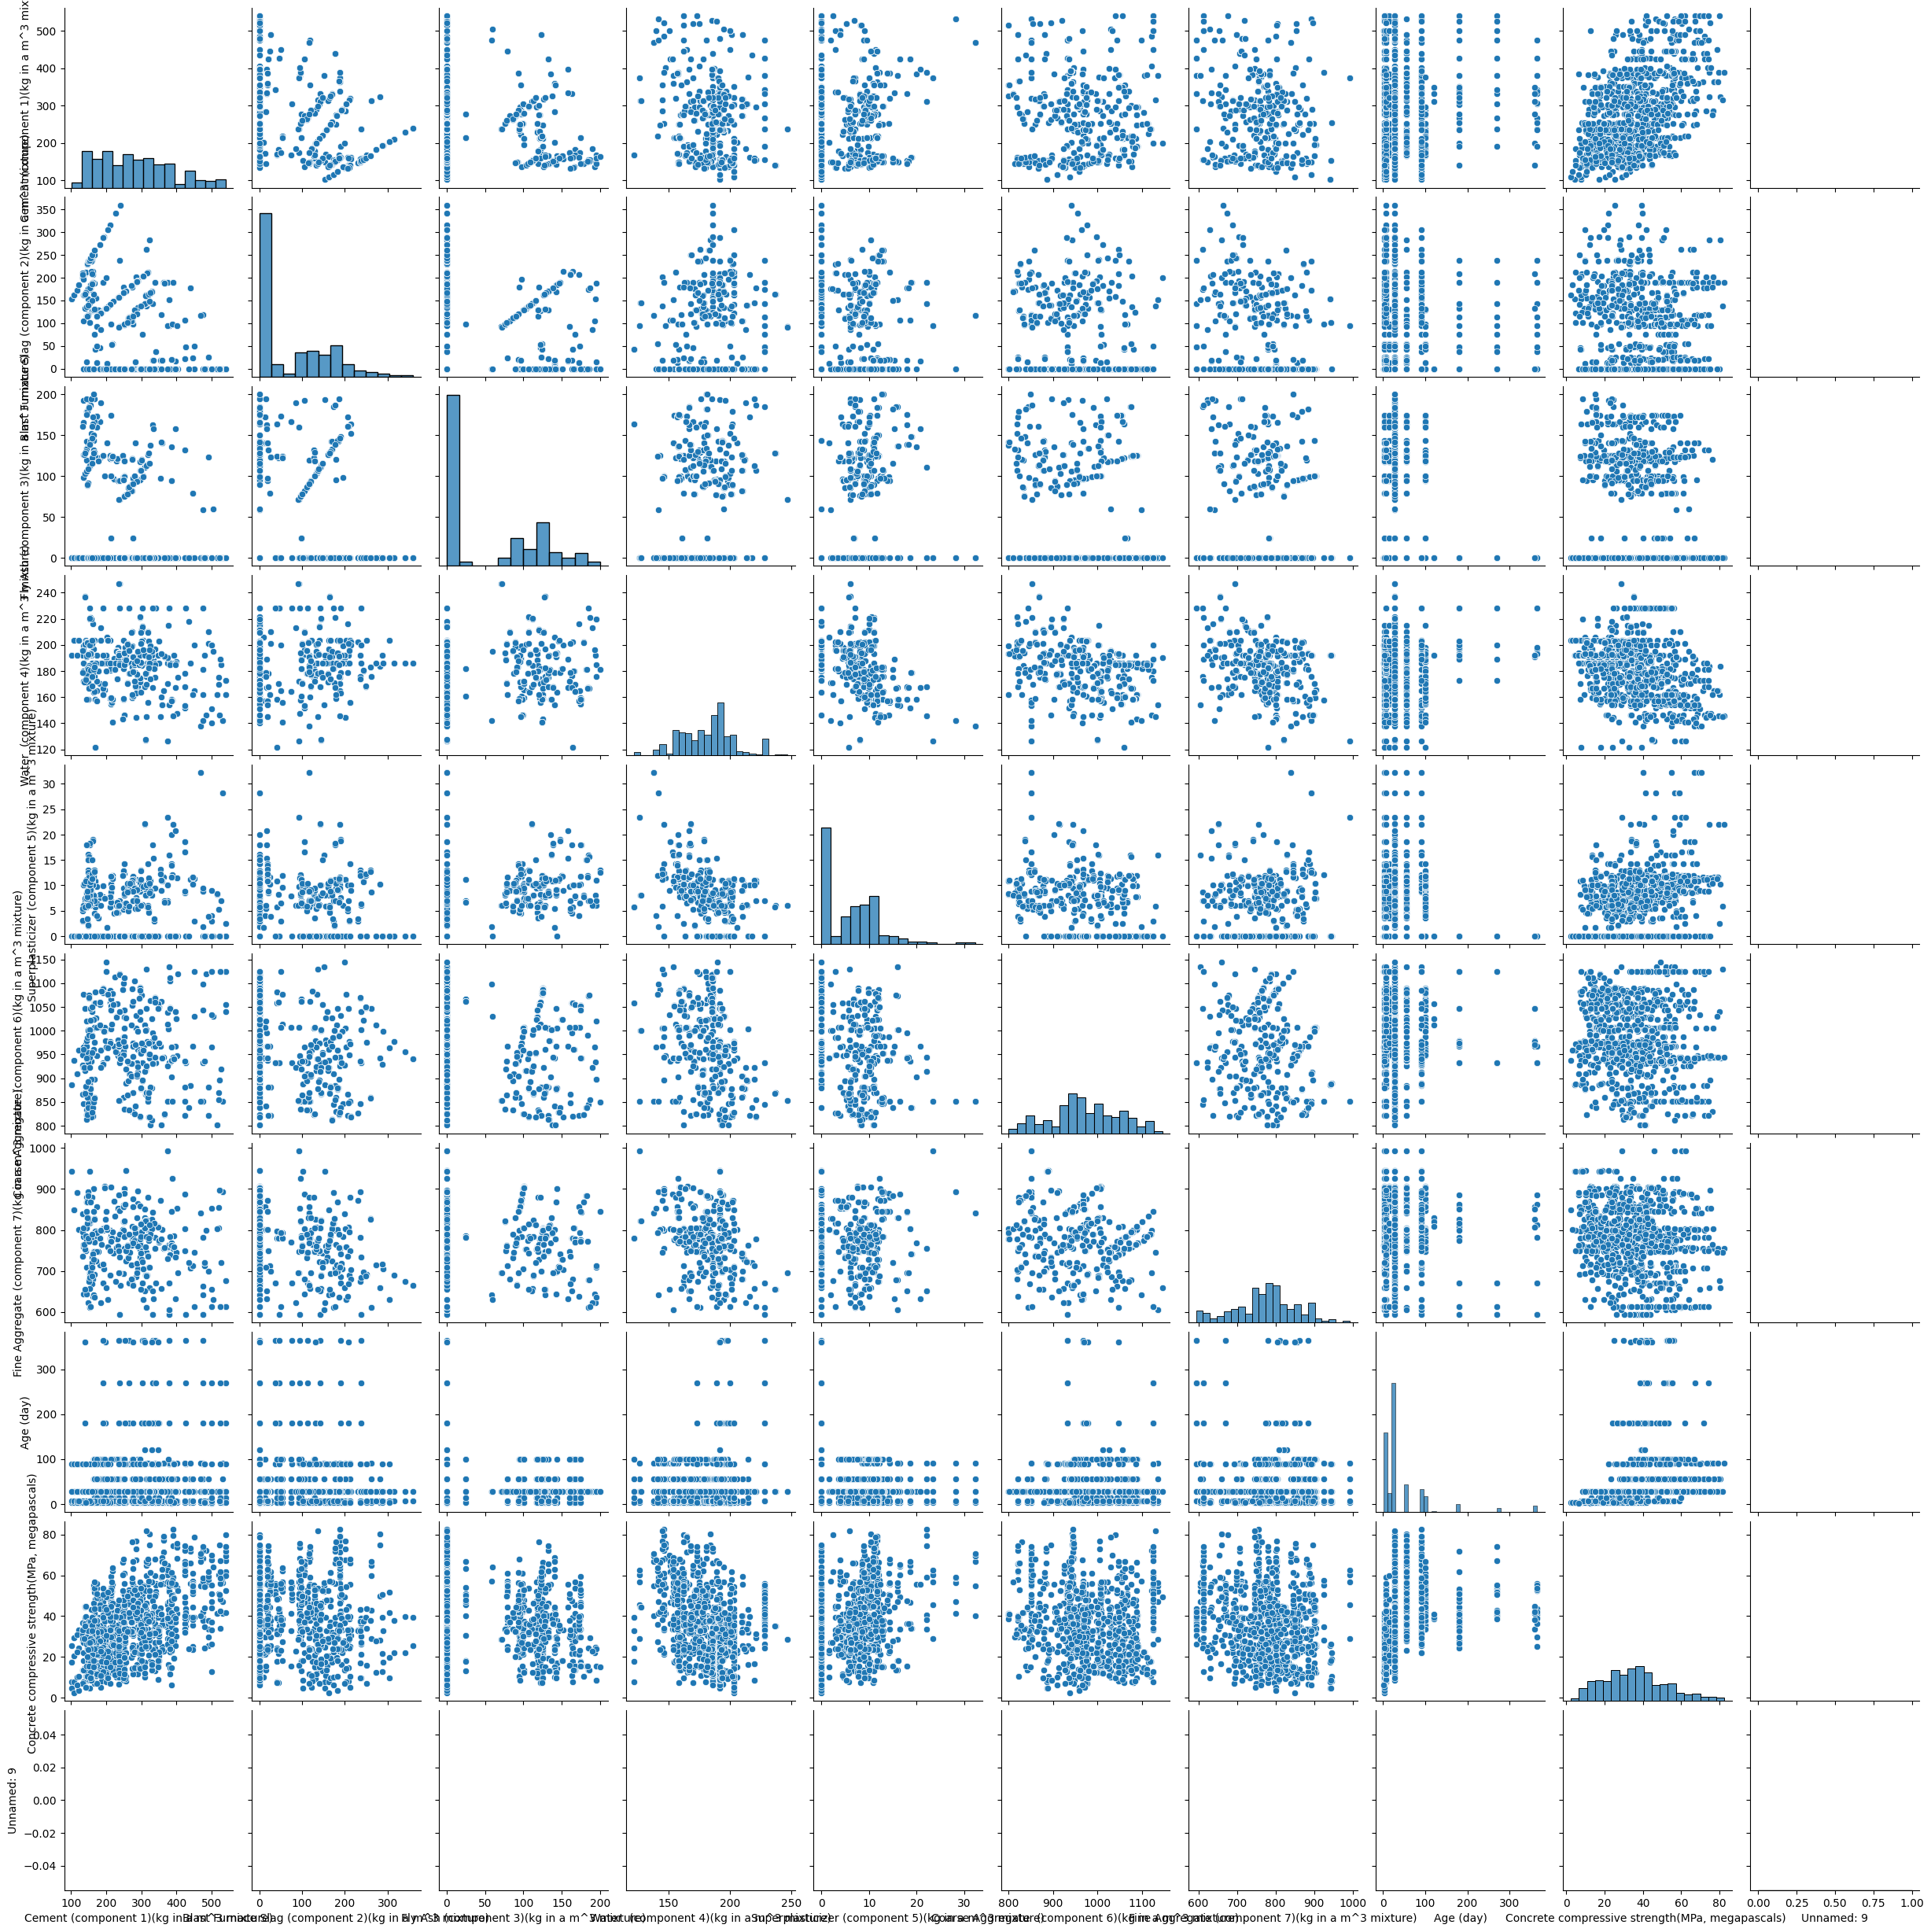

In [14]:
sns.pairplot(df)
plt.show()

# Task 2: Data Cleaning & Transformation 

#### Outlier Detection (Boxplot)

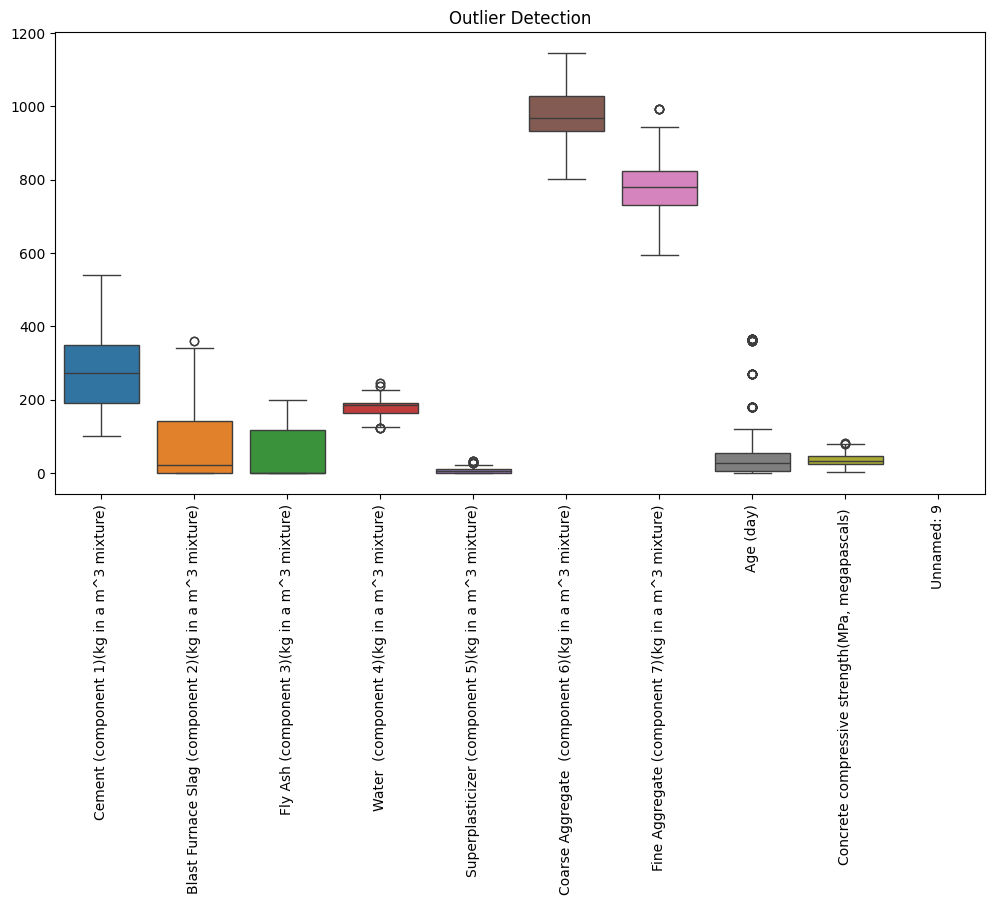

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

#### Handling Missing Values

In [17]:
df = df.fillna(df.mean())

#### Feature Scaling

In [18]:
scaler = StandardScaler()

X = df.drop("Concrete compressive strength(MPa, megapascals) ", axis=1)
y = df["Concrete compressive strength(MPa, megapascals) "]

X_scaled = scaler.fit_transform(X)

c:\Users\Admin\Desktop\mlLab\lab\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Admin\Desktop\mlLab\lab\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Admin\Desktop\mlLab\lab\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


# Task 3:Simple Linear Regression

#### Select Feature

In [19]:
X_simple = df[['Cement (component 1)(kg in a m^3 mixture)']]
y = df['Concrete compressive strength(MPa, megapascals) ']

#### Train Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

#### Train Model

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Prediction

In [22]:
y_pred = model.predict(X_test)

#### Plot Regression Line

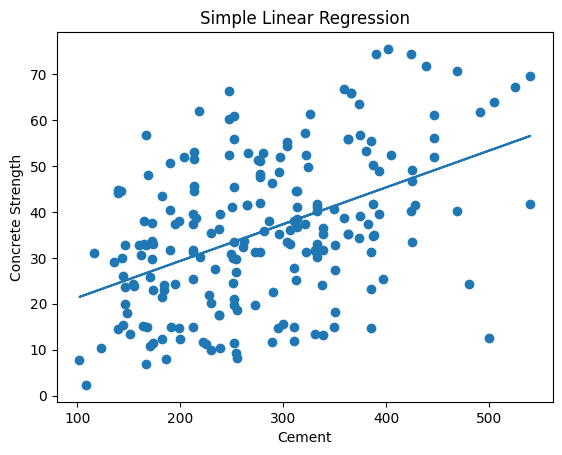

In [23]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Cement")
plt.ylabel("Concrete Strength")
plt.title("Simple Linear Regression")
plt.show()

#### Model Evaluation

In [24]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R2 Score: 0.20575172731355396
MAE: 11.898673078370708
MSE: 210.41458293599783
RMSE: 14.505674163443691


# Task 4: Multiple Linear Regression

#### Define Features

In [25]:
X = df.drop("Concrete compressive strength(MPa, megapascals) ", axis=1)
y = df["Concrete compressive strength(MPa, megapascals) "]

#### Train Model

In [26]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Prediction

In [27]:
y_pred2 = model2.predict(X_test)

#### Evaluation

In [28]:
r2 = r2_score(y_test, y_pred2)
mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R2 Score: 0.20575172731355396
MAE: 11.898673078370708
MSE: 210.41458293599783
RMSE: 14.505674163443691
